In [5]:
#
# Train ICA model for 
#   - Syntactic Context Encoding (The main work of study)
#   - "Wordgram" (windowed n-gram context words)
#
# For D in 1...16 dimension spaces
# Optionally, store the results, by switching on the "store" flag below.
#
# Also evaluate the separability done by a Bayesian GMM model by scoring
# (BGM with 10 components, spherical model)
# with data from the previously stored ICA model
# 
#

import pandas as pd
import numpy as np
import scipy as sp
import sklearn
import importlib
import databox as db
import joblib
from hashlib import md5
# import sample_group_stats as sgst
from sklearn.mixture import BayesianGaussianMixture
from sklearn.decomposition import FastICA



OK -- read the ontology db (19571, 4)
Restored 303734 tags and 191240 tokens. Run update_corpus_tagdata() to update.
-- loaded the skipgram model tank/fasttext_8.model --


In [390]:


ce_df = pd.read_parquet("data/q_sep/context_encoding_df.pq").\
            reset_index().set_index(['category','token_id'])

wg_df = pd.read_parquet("data/q_sep/wordgram_df.pq").\
            reset_index().set_index(['category','token_id'])

# Sort order by token id based hash

ce_df['md5']=[md5(x.encode()).hexdigest() for x in ce_df.index.droplevel(0)]
ce_df.sort_values('md5',inplace=True)
ce_df.drop(columns=['md5'],inplace=True)
wg_df=wg_df.loc[ce_df.index]


for red_dim in list(range(1,17)):
    
    store = False
    
    if store:
    
        # train and store

        wg_tr = FastICA(n_components=red_dim, random_state=42)
        ce_tr = FastICA(n_components=red_dim, random_state=42)
        wg_tr.fit(wg_df.groupby('category').head(2000))
        ce_tr.fit(ce_df.groupby('category').head(2000))


        joblib.dump(wg_tr,'data/q_sep/WG-ICA_transformer_w_%d-dim.pkl' % red_dim)
        joblib.dump(ce_tr,'data/q_sep/CE-ICA_transformer_w_%d-dim.pkl' % red_dim)

    wg_tr = joblib.load('data/q_sep/WG-ICA_transformer_w_%d-dim.pkl' % red_dim)
    ce_tr = joblib.load('data/q_sep/CE-ICA_transformer_w_%d-dim.pkl' % red_dim)    
   
    wg_i = pd.DataFrame(wg_tr.transform(wg_df),index=wg_df.index)
    ce_i = pd.DataFrame(ce_tr.transform(ce_df),index=ce_df.index)
    
    if store:

        wg_i.to_parquet("data/q_sep/WG-ICA_data_%d-dim.pq" % red_dim)
        ce_i.to_parquet("data/q_sep/CE-ICA_data_%d-dim.pq" % red_dim)
    
    wgdf = wg_i
    cedf = ce_i
    categories = cedf.index.droplevel(1).unique()
    bgms = {}
    

    for model_id in ['ce','wg']:
        for cat_id in categories:
            bgm_id = '%s_%s' % (model_id, cat_id)
            bgms[bgm_id]=None
            df = wgdf if model_id=='wg' else cedf

            print ("Fitting %s dataset... (%s)"%(bgm_id,str(df.loc[cat_id].shape)))
            bgm = BayesianGaussianMixture(n_components=10,tol=0.001,max_iter=500,
                                          random_state=42,
                                          covariance_type='spherical')
            bgm.fit(df.loc[cat_id].iloc[0:2000])
            bgms[bgm_id]=bgm
            print("BGM stored")
            
    if store:
            
        joblib.dump(bgms,'data/q_sep/BGMs_%d-dim.pkl' % red_dim)
            

    grid_data = []

    for x in categories:
        for y in categories:
            for m in ['ce','wg']:
                ica_df = (cedf if m=='ce' else wgdf)
                s = bgms[m+'_'+x].score(ica_df.loc[y].iloc[0:2000])
                grid_data.append((m,x,y,s))


    grid_df = pd.DataFrame(grid_data,columns=['projection','BGM_model','test_set','loglhood'])
    grid_df = grid_df.set_index(['projection','BGM_model','test_set']).sort_index()
    
    grid_df['n_dim'] = red_dim
    
    if store:
    
        grid_df.to_parquet('data/q_sep/grid1_%d.pq'%red_dim)
        print('written data/q_sep/grid1_%d.pq'%red_dim)
    
    grid = grid_df.reset_index()
    
    grid_df = pd.crosstab(grid.projection+'_' +grid.BGM_model,
                grid.test_set,
                grid.loglhood,
                aggfunc=sum).round(2)
    
    print(grid_df)




Fitting ce_topic dataset... ((39533, 1))


/home/seppo/.local/lib/python3.10/site-packages/sklearn/mixture/_base.py:268: ConvergenceWarning: Initialization 1 did not converge. Try different init parameters, or increase max_iter, tol or check for degenerate data.
  warnings.warn(


BGM stored
Fitting ce_taxongroup dataset... ((8361, 1))


/home/seppo/.local/lib/python3.10/site-packages/sklearn/mixture/_base.py:268: ConvergenceWarning: Initialization 1 did not converge. Try different init parameters, or increase max_iter, tol or check for degenerate data.
  warnings.warn(


BGM stored
Fitting ce_adaptation dataset... ((3578, 1))
BGM stored
Fitting ce_location dataset... ((2539, 1))
BGM stored
Fitting wg_topic dataset... ((39827, 1))
BGM stored
Fitting wg_taxongroup dataset... ((9373, 1))
BGM stored
Fitting wg_adaptation dataset... ((4226, 1))
BGM stored
Fitting wg_location dataset... ((3277, 1))


/home/seppo/.local/lib/python3.10/site-packages/sklearn/mixture/_base.py:268: ConvergenceWarning: Initialization 1 did not converge. Try different init parameters, or increase max_iter, tol or check for degenerate data.
  warnings.warn(


BGM stored
written data/q_sep/grid1_1.pq
test_set       adaptation  location  taxongroup  topic
row_0                                                 
ce_adaptation       -0.88     -1.23       -1.24  -1.19
ce_location         -0.94     -1.12       -1.22  -1.17
ce_taxongroup       -0.95     -1.24       -1.13  -1.14
ce_topic            -0.92     -1.18       -1.15  -1.11
wg_adaptation       -1.19     -1.38       -1.18  -0.88
wg_location         -1.21     -1.36       -1.22  -0.97
wg_taxongroup       -1.22     -1.44       -1.14  -0.88
wg_topic            -1.46     -1.83       -1.39  -0.73
Fitting ce_topic dataset... ((39533, 2))
BGM stored
Fitting ce_taxongroup dataset... ((8361, 2))
BGM stored
Fitting ce_adaptation dataset... ((3578, 2))
BGM stored
Fitting ce_location dataset... ((2539, 2))
BGM stored
Fitting wg_topic dataset... ((39827, 2))
BGM stored
Fitting wg_taxongroup dataset... ((9373, 2))
BGM stored
Fitting wg_adaptation dataset... ((4226, 2))
BGM stored
Fitting wg_location dataset

/home/seppo/.local/lib/python3.10/site-packages/sklearn/mixture/_base.py:268: ConvergenceWarning: Initialization 1 did not converge. Try different init parameters, or increase max_iter, tol or check for degenerate data.
  warnings.warn(


BGM stored
Fitting ce_taxongroup dataset... ((8361, 8))
BGM stored
Fitting ce_adaptation dataset... ((3578, 8))
BGM stored
Fitting ce_location dataset... ((2539, 8))
BGM stored
Fitting wg_topic dataset... ((39827, 8))
BGM stored
Fitting wg_taxongroup dataset... ((9373, 8))
BGM stored
Fitting wg_adaptation dataset... ((4226, 8))
BGM stored
Fitting wg_location dataset... ((3277, 8))
BGM stored
written data/q_sep/grid1_8.pq
test_set       adaptation  location  taxongroup  topic
row_0                                                 
ce_adaptation       -8.82     -9.49      -11.47  -9.98
ce_location         -9.52     -8.73      -11.64  -9.82
ce_taxongroup       -9.40     -9.33      -10.15  -9.34
ce_topic            -9.33     -9.16      -10.60  -8.94
wg_adaptation       -7.59    -11.07      -10.92  -7.45
wg_location         -9.86     -8.50      -11.79  -7.98
wg_taxongroup       -8.97    -10.66       -9.14  -7.23
wg_topic            -8.77    -10.95      -10.29  -6.53
Fitting ce_topic dataset.

BGM stored
Fitting ce_adaptation dataset... ((3578, 16))
BGM stored
Fitting ce_location dataset... ((2539, 16))
BGM stored
Fitting wg_topic dataset... ((39827, 16))
BGM stored
Fitting wg_taxongroup dataset... ((9373, 16))
BGM stored
Fitting wg_adaptation dataset... ((4226, 16))
BGM stored
Fitting wg_location dataset... ((3277, 16))
BGM stored
written data/q_sep/grid1_16.pq
test_set       adaptation  location  taxongroup  topic
row_0                                                 
ce_adaptation      -18.29    -19.53      -24.89 -20.47
ce_location        -19.47    -17.88      -23.16 -19.77
ce_taxongroup      -19.34    -19.21      -21.14 -19.31
ce_topic           -19.19    -18.90      -21.93 -18.55
wg_adaptation      -16.88    -21.88      -21.05 -15.53
wg_location        -19.22    -18.36      -21.17 -15.77
wg_taxongroup      -18.40    -21.11      -18.81 -15.18
wg_topic           -19.14    -22.56      -21.71 -14.74


In [ ]:
#
# The section below is used to analyze the stored performance data.
#


In [2]:
import dask.dataframe as ddf
grids = ddf.read_parquet('data/q_sep/grid1_*.pq').compute()


In [3]:
# Log likelihoods (for comparison against own / other BGM model)

gdata = grids.reset_index()
gdata['status']=(gdata.test_set!=gdata.BGM_model).astype(str).str.replace('True','other').str.replace('False','same')
ggdata = pd.DataFrame(gdata.groupby(['n_dim','projection','status','test_set']).loglhood.max()).reset_index()
ggdata.tail(16)

,n_dim,projection,status,test_set,loglhood
240,16,ce,other,adaptation,-19.186454
241,16,ce,other,location,-18.902661
242,16,ce,other,taxongroup,-21.930146
243,16,ce,other,topic,-19.313022
244,16,ce,same,adaptation,-18.286436
245,16,ce,same,location,-17.877534
246,16,ce,same,taxongroup,-21.135789
247,16,ce,same,topic,-18.553953
248,16,wg,other,adaptation,-18.397799
249,16,wg,other,location,-21.112213


In [4]:
# Performance table: Comparison with the neighbor model

logl_perf = pd.pivot(ggdata,columns=['projection','status'],index=['test_set','n_dim'])
logl_perf['diff_ce'] = logl_perf.loglhood.ce.same-logl_perf.loglhood.ce.other
logl_perf['diff_wg'] = logl_perf.loglhood.wg.same-logl_perf.loglhood.wg.other
logl_perf.sample(4)

loglhood                                    diff_ce  \
projection               ce                    wg                        
status                other       same      other       same             
test_set   n_dim                                                         
taxongroup 9     -12.064187 -11.444015 -11.463806 -10.220038  0.620172   
adaptation 13    -15.504111 -14.606932 -14.776973 -13.313312  0.897179   
topic      15    -17.897000 -17.281596 -14.268516 -13.504891  0.615403   
taxongroup 15    -20.306788 -19.629905 -19.476435 -17.678740  0.676883   

                   diff_wg  
projection                  
status                      
test_set   n_dim            
taxongroup 9      1.243768  
adaptation 13     1.463661  
topic      15     0.763625  
taxongroup 15     1.797695

Text(0.5, 0.98, 'Log likelihood based difference score for token categories using Bayesian Gaussian Mixtures')

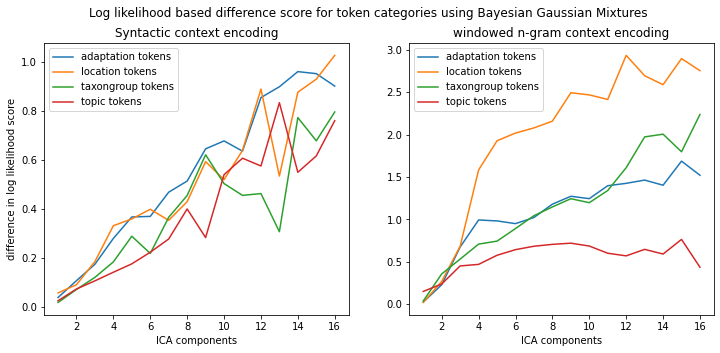

In [6]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(12,5) )

ax1, ax2 = axs

categories = logl_perf.index.droplevel(1).unique()

ll = []
for c in categories:
    d='diff_ce'
    ax1.plot(logl_perf.loc[c][d])
    ll.append(c+" tokens")
ax1.legend(ll)
ax1.set_title("Syntactic context encoding")
ax1.set_xlabel('ICA components')
ax1.set_ylabel('difference in log likelihood score')


ll = []
for c in categories:
    d='diff_wg'
    ax2.plot(logl_perf.loc[c][d])
    ll.append(c+" tokens")
ax2.legend(ll)
ax2.set_title("windowed n-gram context encoding")
ax2.set_xlabel('ICA components')

fig.suptitle('Log likelihood based difference score for token categories'+\
             ' using Bayesian Gaussian Mixtures')


In [7]:
bgms=joblib.load('data/q_sep/BGMs_8-dim.pkl')

[(c,str(bgms['ce_'+c].means_.var(axis=0).round(2))) for c in categories]



[('adaptation', '[0.63 5.44 0.33 0.25 0.55 0.05 0.02 0.36]'),
 ('location', '[0.42 0.15 1.53 0.37 1.69 1.63 1.99 1.67]'),
 ('taxongroup', '[ 0.32  6.8   0.51  0.18  0.39 51.35  2.54  0.97]'),
 ('topic', '[ 0.18  2.48  1.15 20.03  1.82  1.51  1.82  0.99]')]

In [6]:


df = pd.read_parquet('data/q_sep/CE-ICA_data_8-dim.pq')

df.columns = ['IC %s'%d for d in df.columns]
pgd = df[df.columns[[1,2,3,6]]].reset_index().set_index('token_id')
pgd=pgd.groupby('category').sample(200)
pgd.head(10)



,category,IC 1,IC 2,IC 3,IC 6
token_id,,,,,
Sca-9161_32_Scavenger-1,adaptation,-0.449769,0.719499,0.641321,-0.300519
Ame-35ae_147_territorial-7,adaptation,-0.400332,0.430328,0.509603,-0.228489
Par-ce5c_41_migration-25,adaptation,0.113835,0.167363,0.661505,0.720588
Cap-5548_7_social-5,adaptation,0.375903,-2.322331,-0.034000,-0.855257
Gol-1dbf_377_predators-12,adaptation,0.853262,-0.564174,-1.567875,-0.370733
Eri-31f4_17_nocturnal-7,adaptation,-0.727335,-0.223611,0.981382,0.236592
Eur-d570_91_migration-10,adaptation,-0.368013,0.438852,-0.150152,0.000629
Bow-5df3_233_migrations-23,adaptation,0.073863,-1.201332,-0.850751,-0.388524
Pre-0725_27_scavengers-13,adaptation,-0.143922,-1.011982,0.415348,-0.011764


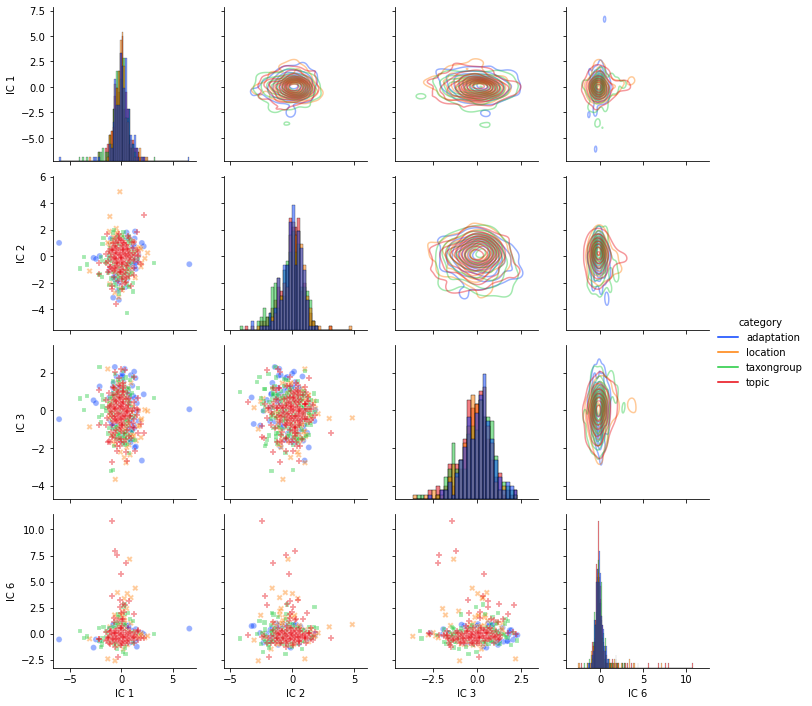

In [8]:
import seaborn as sns

marker_map = {'adaptation':'.',
           'location':'+',
           'topic':'x',
           'taxongroup':'o'
           }

sns.set_palette(sns.color_palette("bright",n_colors=4))
g = sns.PairGrid(pgd,hue='category')
g.map_lower(sns.scatterplot,style=pgd.category,alpha=0.4)
g.map_upper(sns.kdeplot,alpha=0.4)
g.map_diag(sns.histplot)
g.add_legend()


In [33]:
g8=grids[grids.n_dim==8][['loglhood']].reset_index()
g8_score = pd.crosstab(g8.projection+ ' '+ g8.BGM_model,g8.test_set,values=g8.loglhood,aggfunc=sum).round(2)
g8_score.index.name='BGM model'
g8_score.columns.name='test set'
g8_score.astype(str)

test set,adaptation,location,taxongroup,topic
BGM model,,,,
ce adaptation,-8.82,-9.49,-11.47,-9.98
ce location,-9.52,-8.73,-11.64,-9.82
ce taxongroup,-9.4,-9.33,-10.15,-9.34
ce topic,-9.33,-9.16,-10.6,-8.94
wg adaptation,-7.59,-11.07,-10.92,-7.45
wg location,-9.86,-8.5,-11.79,-7.98
wg taxongroup,-8.97,-10.66,-9.14,-7.23
wg topic,-8.77,-10.95,-10.29,-6.53


In [34]:
print(g8_score.astype(str).to_latex())

\begin{tabular}{lllll}
\toprule
test set & adaptation & location & taxongroup & topic \\
BGM model &  &  &  &  \\
\midrule
ce adaptation & -8.82 & -9.49 & -11.47 & -9.98 \\
ce location & -9.52 & -8.73 & -11.64 & -9.82 \\
ce taxongroup & -9.4 & -9.33 & -10.15 & -9.34 \\
ce topic & -9.33 & -9.16 & -10.6 & -8.94 \\
wg adaptation & -7.59 & -11.07 & -10.92 & -7.45 \\
wg location & -9.86 & -8.5 & -11.79 & -7.98 \\
wg taxongroup & -8.97 & -10.66 & -9.14 & -7.23 \\
wg topic & -8.77 & -10.95 & -10.29 & -6.53 \\
\bottomrule
\end{tabular}



>>> ce_df.reset_index().category.value_counts()
```
category
topic         39533
taxongroup     8361
adaptation     3578
location       2539
Name: count, dtype: int64
```